### Celda 1 — Importar librerías
Carga de librerías para análisis de datos, visualización y modelado. 📦

In [3]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path para importar scripts/
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Motor de base de datos reutilizando database.py del proyecto
from scripts.database import engine

# Estilo visual consistente
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías importadas correctamente
   pandas      2.2.0
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.4


# 📌 Fase 2 - Conexión a PostgreSQL
Conexión al motor de base de datos y preparación del entorno para análisis.

### Celda 2 — Cargar datos
Extracción de datos desde PostgreSQL mediante consulta SQL. 🗄️

In [13]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────

QUERY = """
SELECT
    s.id,
    s.nombre,
    s.editorial,

    AVG(p.inteligencia) AS inteligencia,
    AVG(p.fuerza) AS fuerza,
    AVG(p.velocidad) AS velocidad,
    AVG(p.durabilidad) AS durabilidad,
    AVG(p.poder) AS poder,
    AVG(p.combate) AS combate

FROM superheroes s
JOIN powerstats p 
    ON s.id = p.superhero_id

WHERE s.activo = true

GROUP BY s.id, s.nombre, s.editorial;
"""

df = pd.read_sql(QUERY, engine)

print("✅ Datos cargados exitosamente desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print("\n📋 Primeras filas:")
df.head()

✅ Datos cargados exitosamente desde PostgreSQL
   Filas    : 14
   Columnas : 9

📋 Primeras filas:


,id,nombre,editorial,inteligencia,fuerza,velocidad,durabilidad,poder,combate
0,4,Hulk,None,77.400826,52.000000,65.053719,69.599174,67.061983,93.206612
1,14,Captain Marvel II,None,90.221790,65.836576,52.832685,71.132296,71.988327,84.852140
2,3,Wonder Woman,None,86.948905,67.062044,90.043796,61.704380,74.791971,60.306569
3,13,Captain Marvel,None,52.823293,92.622490,70.128514,89.726908,76.188755,80.192771
4,10,Captain Mar-vell,None,74.738281,89.140625,52.394531,88.265625,77.351562,86.921875


## Celda 3 — Inspección inicial del DataFrame
Verifica tipos de datos, valores nulos y forma general del dataset.🔍

In [14]:
# ── CELDA 3: Inspección inicial del DataFrame ─────────────────

print("=" * 55)
print("  INFORMACIÓN GENERAL DEL DATASET - SUPERHÉROES")
print("=" * 55)

print(df.info())

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

print("\n🦸‍♂️ Superhéroes en el dataset:")
print(df['nombre'].value_counts())

print("\n📚 Distribución por editorial:")
print(df['editorial'].value_counts())

  INFORMACIÓN GENERAL DEL DATASET - SUPERHÉROES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            14 non-null     int64  
 1   nombre        14 non-null     object 
 2   editorial     0 non-null      object 
 3   inteligencia  14 non-null     float64
 4   fuerza        14 non-null     float64
 5   velocidad     14 non-null     float64
 6   durabilidad   14 non-null     float64
 7   poder         14 non-null     float64
 8   combate       14 non-null     float64
dtypes: float64(6), int64(1), object(2)
memory usage: 1.1+ KB
None

📊 Valores nulos por columna:
id               0
nombre           0
editorial       14
inteligencia     0
fuerza           0
velocidad        0
durabilidad      0
poder            0
combate          0
dtype: int64

🦸‍♂️ Superhéroes en el dataset:
nombre
Captain Marvel       2
Hulk                 1
Captain Ma

# 📌 Fase 3 - Análisis Exploratorio de Datos (EDA)
Exploración de patrones, distribuciones y relaciones entre variables.

### Celda 4 — Estadísticas descriptivas[texto del enlace](https://)
Resumen numérico de variables clave del dataset. 📊

In [15]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────

vars_num = [
    'inteligencia',
    'fuerza',
    'velocidad',
    'durabilidad',
    'combate',
    'poder'
]

# ── ESTADÍSTICAS CON FILAS RESALTADAS ───────────────────────

desc = df[vars_num].describe().round(2)

def resaltar_filas(row):
    # Definimos los colores (puedes cambiarlos a tu gusto)
    color_promedio = 'background-color: #D6EAF8' # Azul claro
    color_mediana = 'background-color: #D5F5E3'  # Verde claro

    if row.name == 'mean':
        return [color_promedio] * len(row)
    if row.name == '50%':
        return [color_mediana] * len(row)
    return [''] * len(row)

# Aplicamos el estilo
styled_table = desc.style.apply(resaltar_filas, axis=1) \
    .format("{:.2f}") \
    .set_caption("📊 ESTADÍSTICAS DESCRIPTIVAS — POWERSTATS")

# Mostrar
styled_table

,inteligencia,fuerza,velocidad,durabilidad,combate,poder
count,14.00,14.00,14.00,14.00,14.00,14.00
mean,68.27,76.60,70.38,77.64,75.52,72.85
std,14.96,13.22,14.95,10.97,10.47,5.32
min,50.17,52.00,50.82,56.39,60.31,65.22
25%,54.53,68.81,53.59,69.98,68.70,69.70
50%,66.65,79.11,74.58,79.35,78.33,72.70
75%,76.74,85.31,83.90,86.89,83.69,75.93
max,92.43,92.62,90.04,91.65,93.21,85.08


### Celda 5 — Distribución de variables numéricas
Histogramas para detectar asimetría, outliers y rangos. 📈

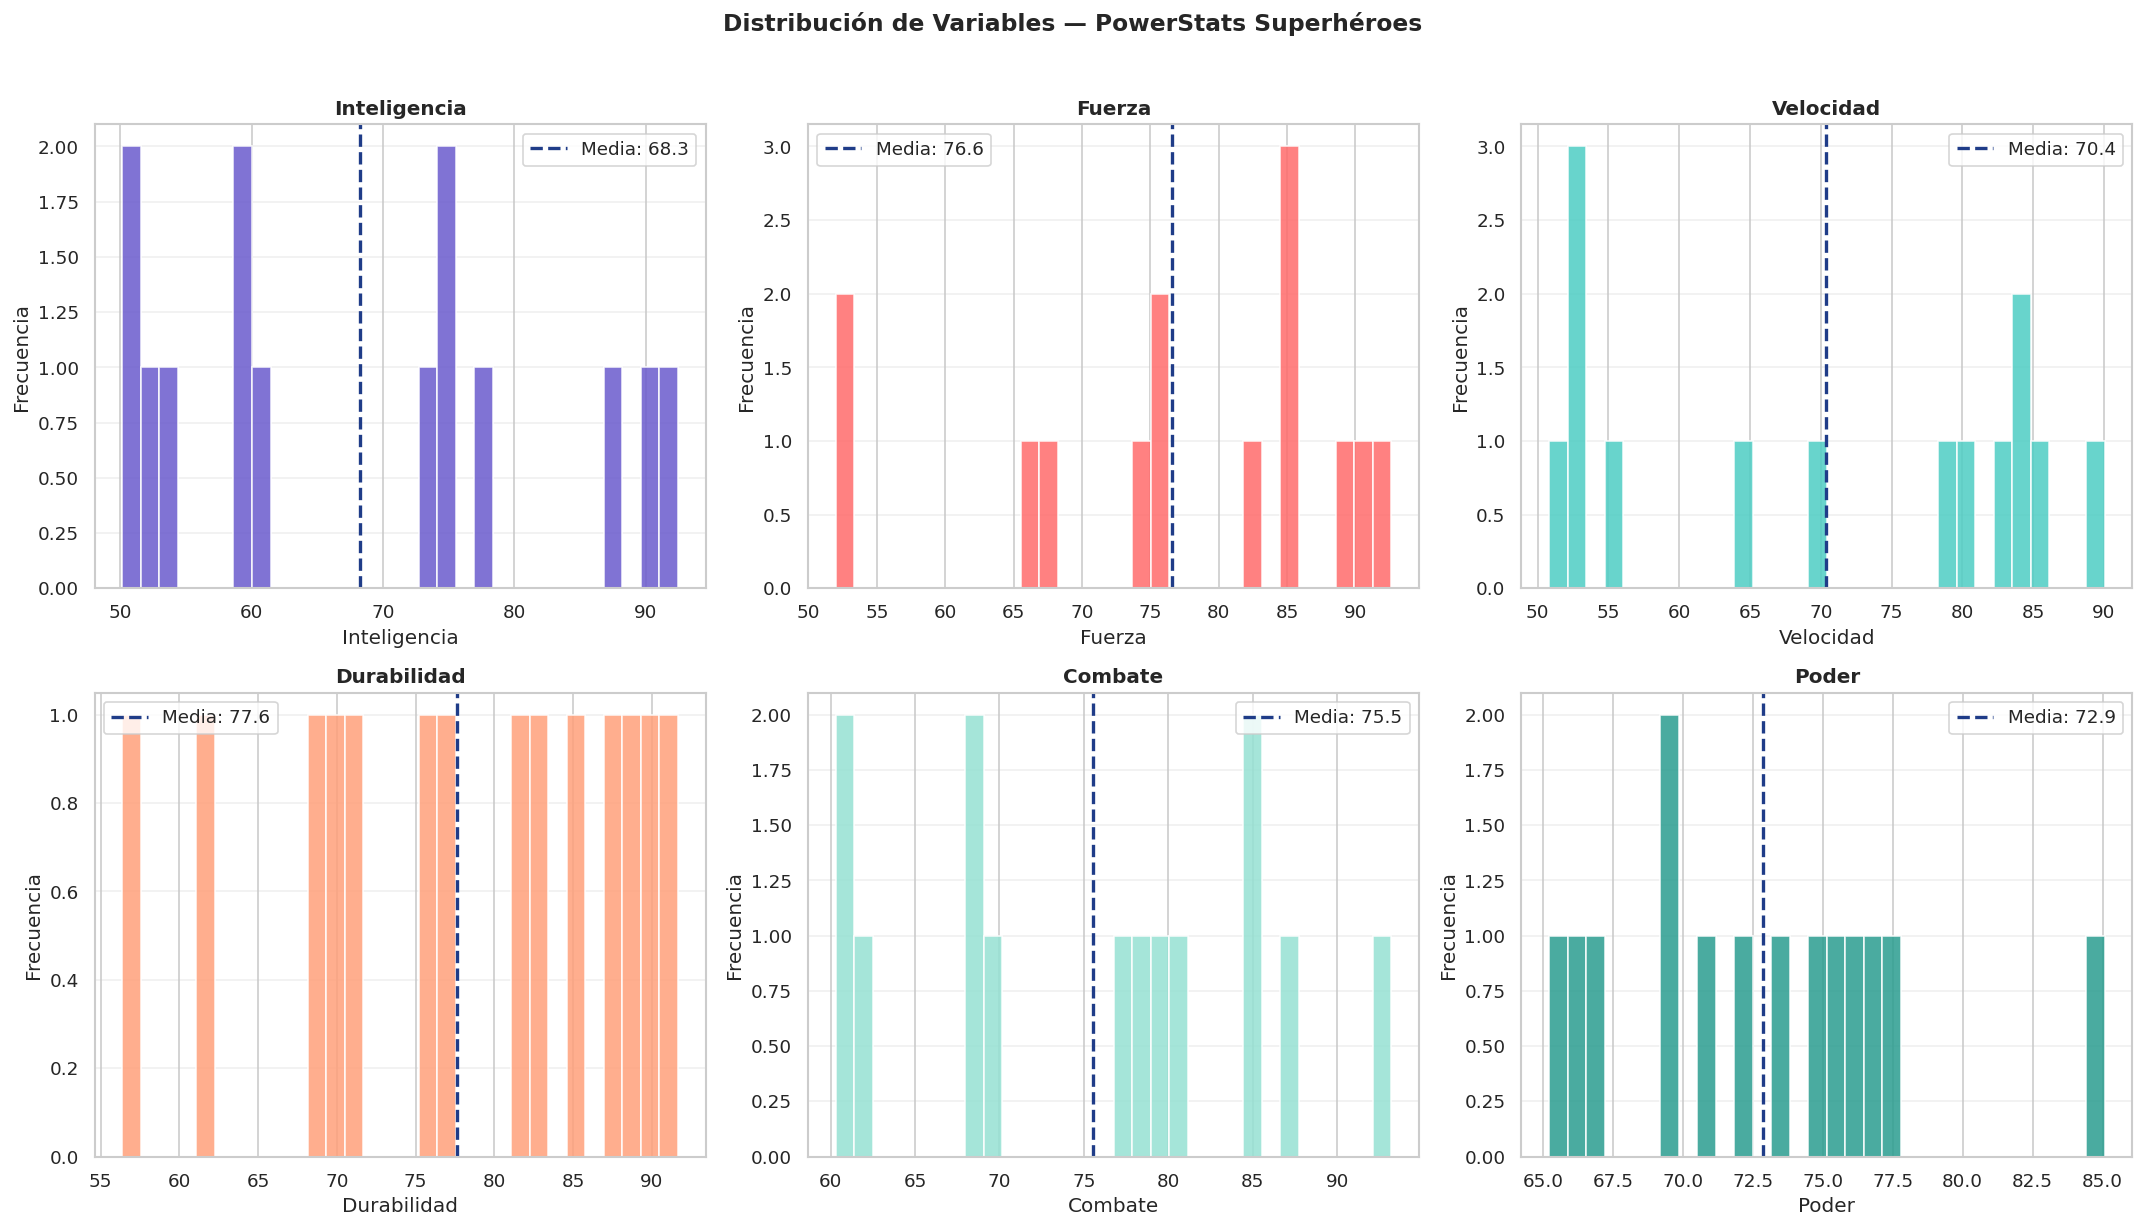

In [16]:
# ── CELDA 5: Histogramas de distribución ─────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'Distribución de Variables — PowerStats Superhéroes',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

datos = {
    'inteligencia': ('Inteligencia', '#6a5acd'),
    'fuerza':       ('Fuerza', '#ff6b6b'),
    'velocidad':    ('Velocidad', '#4ecdc4'),
    'durabilidad':  ('Durabilidad', '#ffa07a'),
    'combate':      ('Combate', '#95e1d3'),
    'poder':        ('Poder', '#2a9d8f'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    media = df[col].mean()
    ax.axvline(
        media,
        color='#1f3c88',
        linestyle='--',
        linewidth=2,
        label=f'Media: {media:.1f}'
    )
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    '../data/graficas/eda_distribuciones_powerstats.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

### Celda 6 — Boxplots por superhéroe (Top 10 por poder)
Visualiza la distribución de las métricas de **fuerza** y **poder** para los 10 superhéroes con mayor poder promedio.  

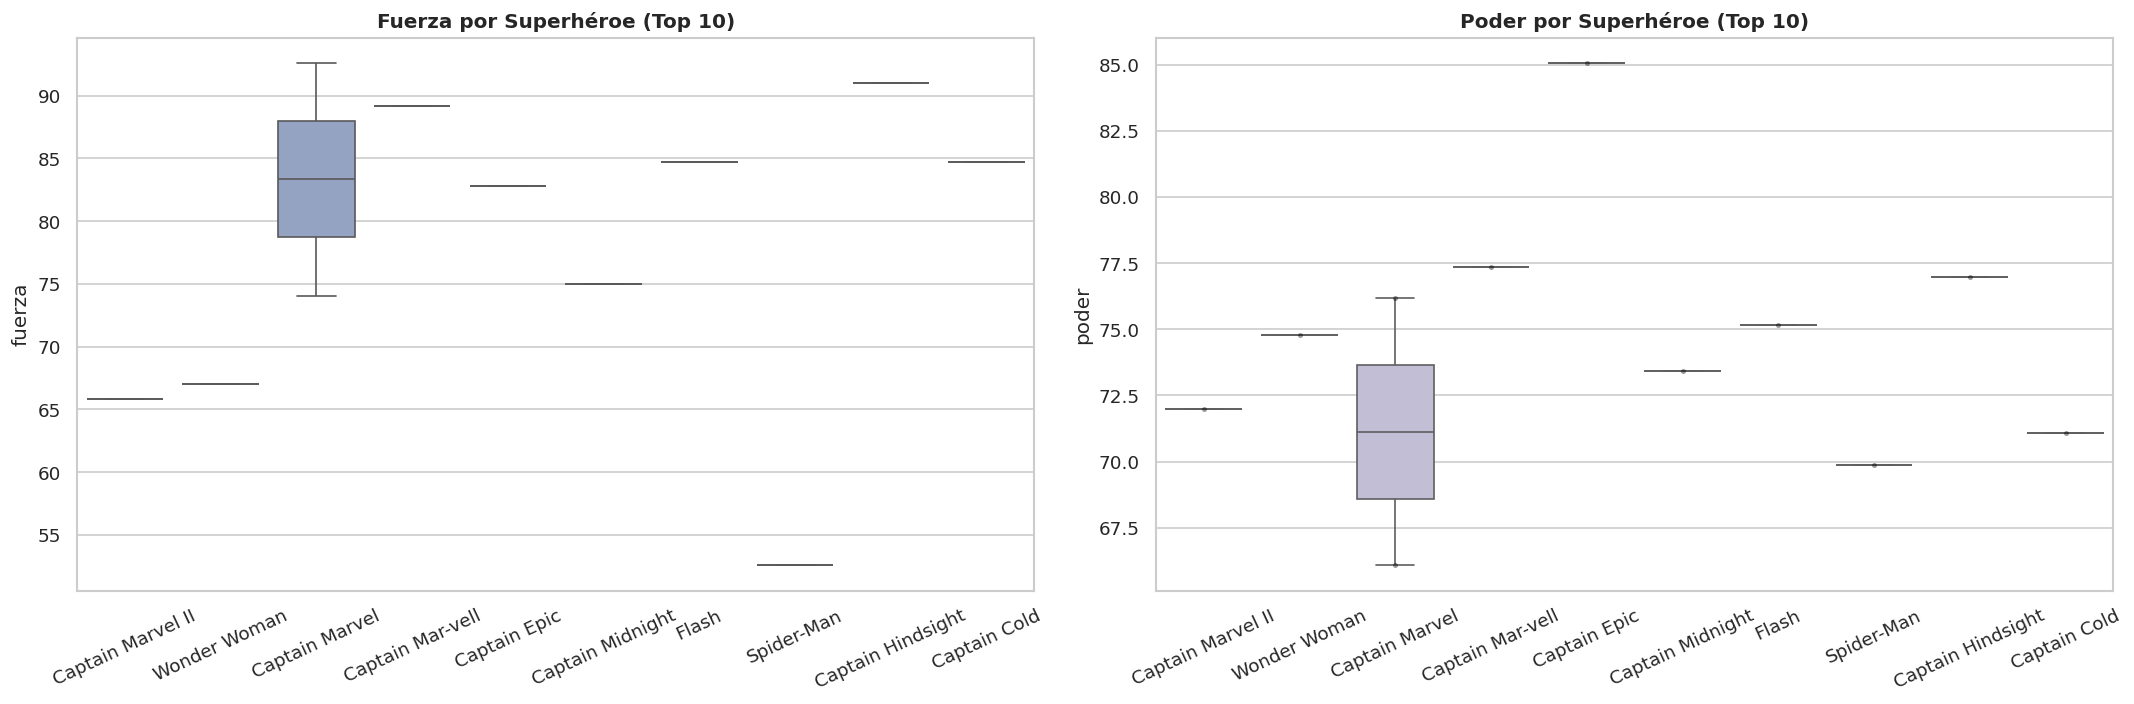

In [20]:
# ── CELDA 6: Boxplots por Superhéroe (Top 10 por Poder) ──────

# Seleccionar top 10 superhéroes por poder promedio
top_heroes = (
    df.groupby('nombre')['poder']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

df_top = df[df['nombre'].isin(top_heroes)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Fuerza por superhéroe ─────────────────────────────
sns.boxplot(
    data=df_top,
    x='nombre',
    y='fuerza',
    hue='nombre',
    palette='Set2',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Fuerza por Superhéroe (Top 10)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)

# ── Poder por superhéroe (boxplot + puntos) ───────────
sns.boxplot(
    data=df_top,
    x='nombre',
    y='poder',
    hue='nombre',          # 🔑 CLAVE
    palette='Set3',
    legend=False,
    ax=axes[1]
)

sns.stripplot(
    data=df_top,
    x='nombre',
    y='poder',
    color='black',
    size=3,
    alpha=0.4,
    jitter=True,
    ax=axes[1]
)

axes[1].set_title('Poder por Superhéroe (Top 10)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(
    '../data/graficas/eda_boxplots_nombres.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

### Celda 7 — Matriz de correlación
Identificación de relaciones entre variables numéricas. 🔗

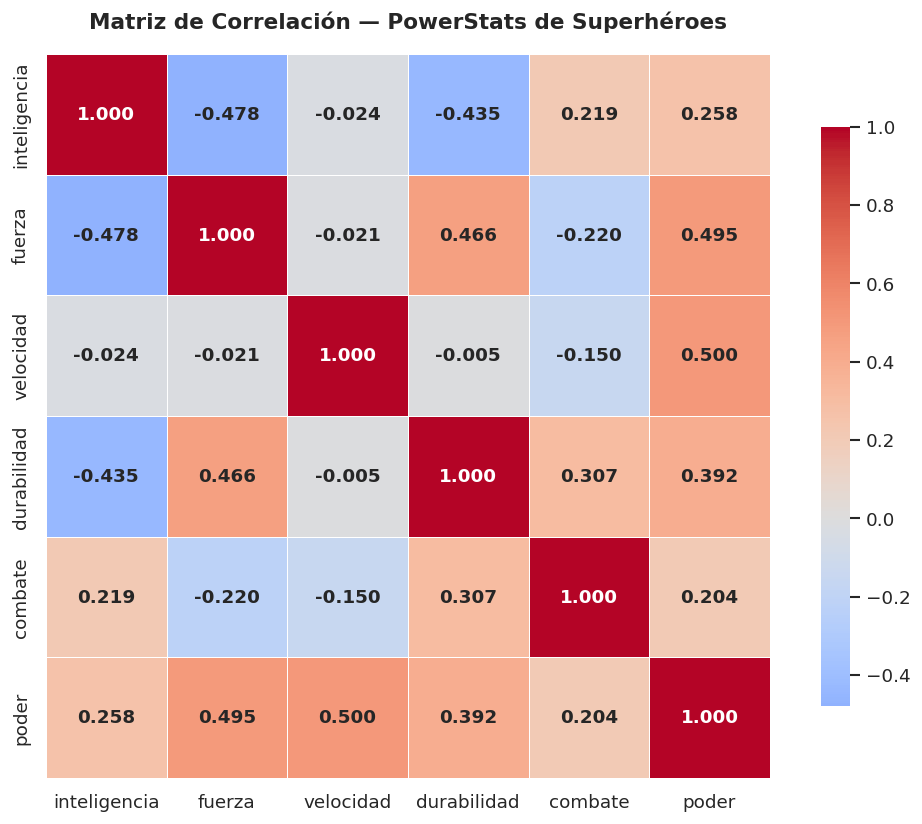


📊 Correlación con PODER (ordenada):
velocidad       0.5003
fuerza          0.4948
durabilidad     0.3919
inteligencia    0.2576
combate         0.2040
Name: poder, dtype: float64


In [21]:
# ── CELDA 7: Matriz de correlación ───────────────────────────

corr = df[vars_num].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.6,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 11, 'weight': 'bold'}
)

plt.title(
    'Matriz de Correlación — PowerStats de Superhéroes',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.savefig(
    '../data/graficas/eda_correlacion_powerstats.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

print("\n📊 Correlación con PODER (ordenada):")
print(
    corr['poder']
    .drop('poder')
    .sort_values(ascending=False)
    .round(4)
)

## Celda 8 — Scatter plots bivariados
Visualiza la relación lineal entre las features y la variable objetivo (poder). 🎯


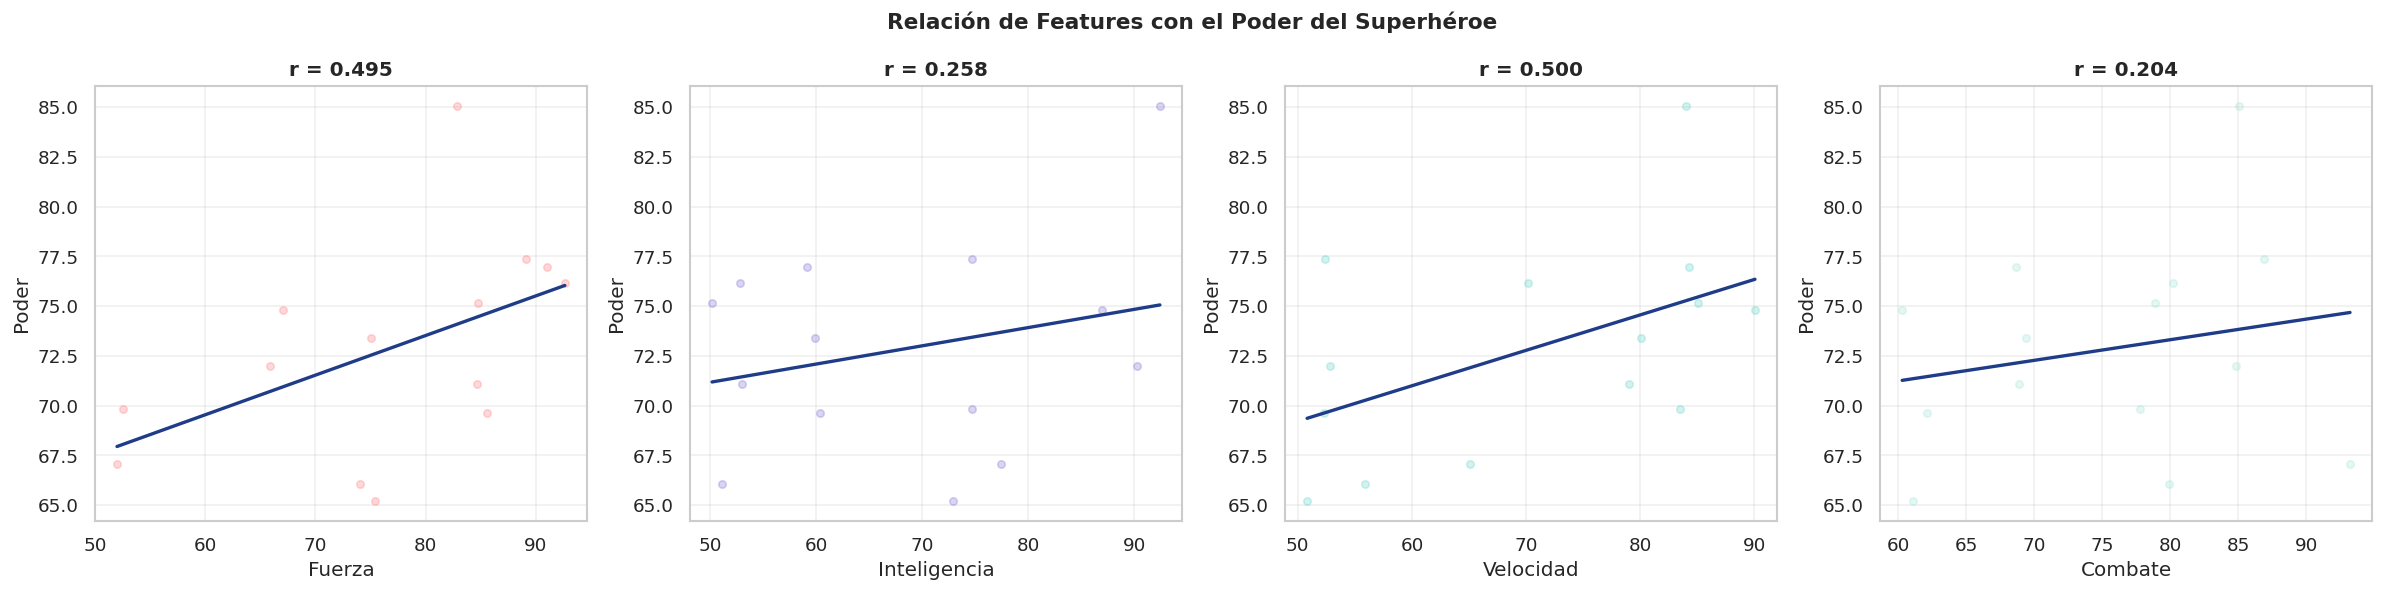

In [22]:
# ── CELDA 8: Scatter plots features vs poder (ROBUSTA) ───────

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    'Relación de Features con el Poder del Superhéroe',
    fontsize=13,
    fontweight='bold'
)

pares = [
    ('fuerza',       'Fuerza',       '#ff6b6b'),
    ('inteligencia', 'Inteligencia', '#6a5acd'),
    ('velocidad',    'Velocidad',    '#4ecdc4'),
    ('combate',      'Combate',      '#95e1d3'),
]

for ax, (feature, xlabel, color) in zip(axes, pares):
    # Seleccionar solo datos válidos
    df_clean = df[[feature, 'poder']].copy()

    # Convertir a numérico y limpiar
    df_clean[feature] = pd.to_numeric(df_clean[feature], errors='coerce')
    df_clean['poder'] = pd.to_numeric(df_clean['poder'], errors='coerce')
    df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna()

    # Scatter
    ax.scatter(
        df_clean[feature],
        df_clean['poder'],
        alpha=0.25,
        s=20,
        color=color
    )

    # Solo ajustar línea si hay suficientes datos
    if len(df_clean) > 2 and df_clean[feature].nunique() > 1:
        z = np.polyfit(df_clean[feature], df_clean['poder'], 1)
        p = np.poly1d(z)
        xp = np.linspace(
            df_clean[feature].min(),
            df_clean[feature].max(),
            200
        )
        ax.plot(xp, p(xp), color='#1f3c88', linewidth=2)

        r = df_clean[[feature, 'poder']].corr().iloc[0, 1]
        ax.set_title(f'r = {r:.3f}', fontweight='bold')
    else:
        ax.set_title('Datos insuficientes', fontweight='bold')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Poder')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    '../data/graficas/eda_scatter_powerstats.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# 📌 Fase 4 - Regresión Lineal Simple
Modelo para analizar relación entre fuerza y poder.

## Celda 9 — Preparar datos y dividir train/test
División del dataset en entrenamiento y prueba. ⚙️

In [25]:
# ── CELDA 9: Preparar datos y Split Train / Test (LIMPIO) ────

# Seleccionar solo filas válidas para regresión
df_modelo = df[['fuerza', 'poder']].dropna()

# Variables
X_simple = df_modelo[['fuerza']].values
y = df_modelo['poder'].values

# División 80% / 20%
X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=42
)

print("✅ Dataset limpio para regresión")
print(f"Filas totales usadas : {len(df_modelo):,}")
print(f"Train: {len(X_train):,} muestras ({len(X_train)/len(y)*100:.0f}%)")
print(f"Test : {len(X_test):,} muestras  ({len(X_test)/len(y)*100:.0f}%)")

✅ Dataset limpio para regresión
Filas totales usadas : 14
Train: 11 muestras (79%)
Test : 3 muestras  (21%)


### Celda 10 — Entrenar el modelo (scikit-learn)
Ajuste del modelo de regresión lineal simple. 🧠


In [26]:
# ── CELDA 10: Entrenamiento con scikit-learn ──────────────────

modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

# Predicciones
y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}")

print(
    f"\nEcuación : poder = {modelo_simple.intercept_:.3f}"
    f" + {modelo_simple.coef_[0]:.3f} × fuerza"
)

Intercepto  β₀ : 59.7960
Coeficiente β₁ : 0.1793

Ecuación : poder = 59.796 + 0.179 × fuerza


### Celda 11 — Visualizar la recta de regresión
Representación gráfica de la recta de regresión. 📉

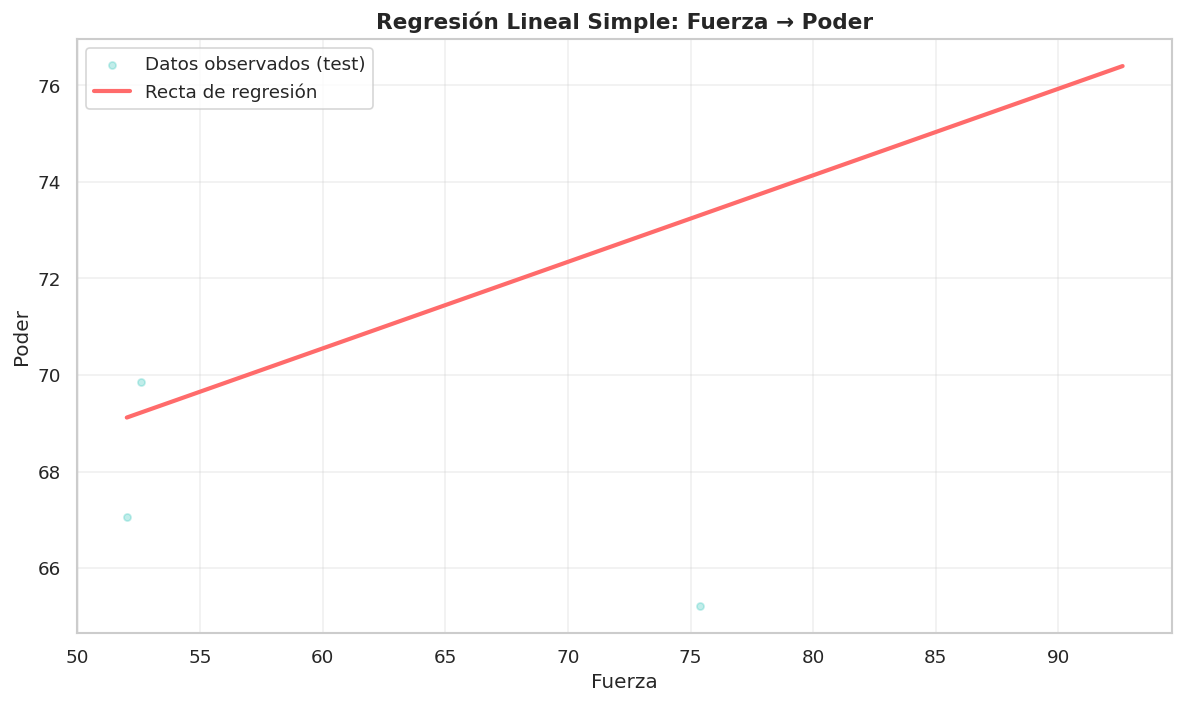

In [27]:
# ── CELDA 11: Recta de regresión ─────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter de datos reales (test)
ax.scatter(
    X_test,
    y_test,
    alpha=0.35,
    s=18,
    color='#4ecdc4',
    label='Datos observados (test)'
)

# Recta de regresión
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(
    x_line,
    modelo_simple.predict(x_line),
    color='#ff6b6b',
    linewidth=2.5,
    label='Recta de regresión'
)

ax.set_xlabel('Fuerza', fontsize=12)
ax.set_ylabel('Poder', fontsize=12)
ax.set_title(
    'Regresión Lineal Simple: Fuerza → Poder',
    fontsize=13,
    fontweight='bold'
)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    '../data/graficas/regresion_simple_fuerza_poder.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

### Celda 12 — Métricas de evaluación
Medición del rendimiento del modelo con métricas. 📏

In [28]:
# ── CELDA 12: Métricas del modelo simple ─────────────────────

r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print("=" * 50)
print("    MÉTRICAS — REGRESIÓN LINEAL SIMPLE (SUPERHÉROES)")
print("=" * 50)
print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med) : {mse:.4f}")
print(f"  RMSE (raíz del MSE)         : {rmse:.4f}")
print(f"  MAE  (error absoluto med)   : {mae:.4f}")
print("=" * 50)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE (SUPERHÉROES)
  R²   (coef. determinación)  : -5.4372  (-543.72%)
  MSE  (error cuadrático med) : 23.3385
  RMSE (raíz del MSE)         : 4.8310
  MAE  (error absoluto med)   : 3.5925


### Celda 13 — Resumen OLS con statsmodels
Análisis estadístico detallado del modelo. 📚

In [29]:
# ── CELDA 13: OLS statsmodels — resumen completo (CORREGIDA) ──

# Usar el mismo DataFrame limpio que en la regresión
df_ols = df_modelo.copy()

# Variable explicativa con constante
X_ols = sm.add_constant(df_ols['fuerza'])

# Variable objetivo
y_ols = df_ols['poder']

# Ajuste del modelo OLS
modelo_ols_simple = sm.OLS(y_ols, X_ols).fit()

# Mostrar resumen
print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  poder   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     3.891
Date:                Thu, 07 May 2026   Prob (F-statistic):             0.0720
Time:                        23:39:48   Log-Likelihood:                -40.783
No. Observations:                  14   AIC:                             85.57
Df Residuals:                      12   BIC:                             86.84
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         57.5909      7.842      7.344      0.0

/home/asus/Documentos/Grupo5.Ramirez.Solano_MD1/10_jupyter_notebook_linux_superheroes/venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)


### Celda 14 — Normalidad de residuos: Histograma + Q-Q Plot + Test Shapiro-Wilk
Validación del supuesto de normalidad en errores. 🔬

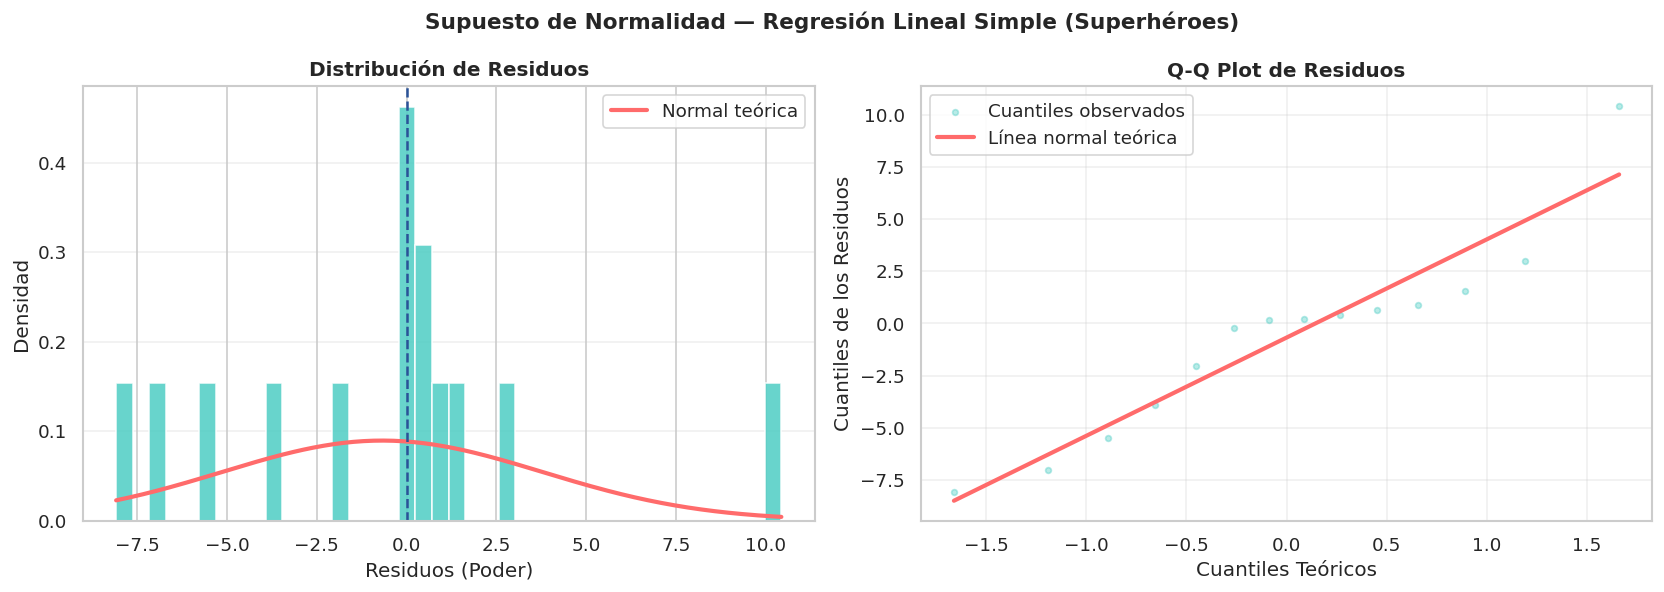


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9182
   p-value       : 0.207060
   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)


In [30]:
# ── CELDA 14: Normalidad de residuos (modelo simple) ─────────

# Predicciones sobre el dataset limpio
y_pred_all = modelo_simple.predict(df_modelo[['fuerza']].values)

# Residuos
residuos = df_modelo['poder'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Supuesto de Normalidad — Regresión Lineal Simple (Superhéroes)',
    fontsize=13,
    fontweight='bold'
)

# -------------------------------------------------
# Histograma con curva normal
# -------------------------------------------------
axes[0].hist(
    residuos,
    bins=40,
    color='#4ecdc4',
    edgecolor='white',
    density=True,
    alpha=0.85
)

xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(
    xr,
    stats.norm.pdf(xr, residuos.mean(), residuos.std()),
    color='#ff6b6b',
    linewidth=2.5,
    label='Normal teórica'
)
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (Poder)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# -------------------------------------------------
# Q-Q Plot
# -------------------------------------------------
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')

axes[1].scatter(
    osm,
    osr,
    alpha=0.4,
    s=12,
    color='#4ecdc4',
    label='Cuantiles observados'
)
axes[1].plot(
    osm,
    slope * np.array(osm) + intercept,
    color='#ff6b6b',
    linewidth=2.5,
    label='Línea normal teórica'
)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    '../data/graficas/normalidad_simple_superheroes.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# -------------------------------------------------
# Test Shapiro-Wilk (máx 5000 observaciones)
# -------------------------------------------------
rng = np.random.default_rng(42)
muestra_sw = (
    residuos if len(residuos) <= 5000
    else rng.choice(residuos, 5000, replace=False)
)

stat_sw, p_sw = stats.shapiro(muestra_sw)

print("\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")

if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: Con muestras grandes, el test es muy sensible; revisar Q-Q plot")

### Celda 15 — Homocedasticidad: Residuos vs Valores Ajustados + Test Breusch-Pagan
Evaluación de la varianza constante en los residuos. ⚖️

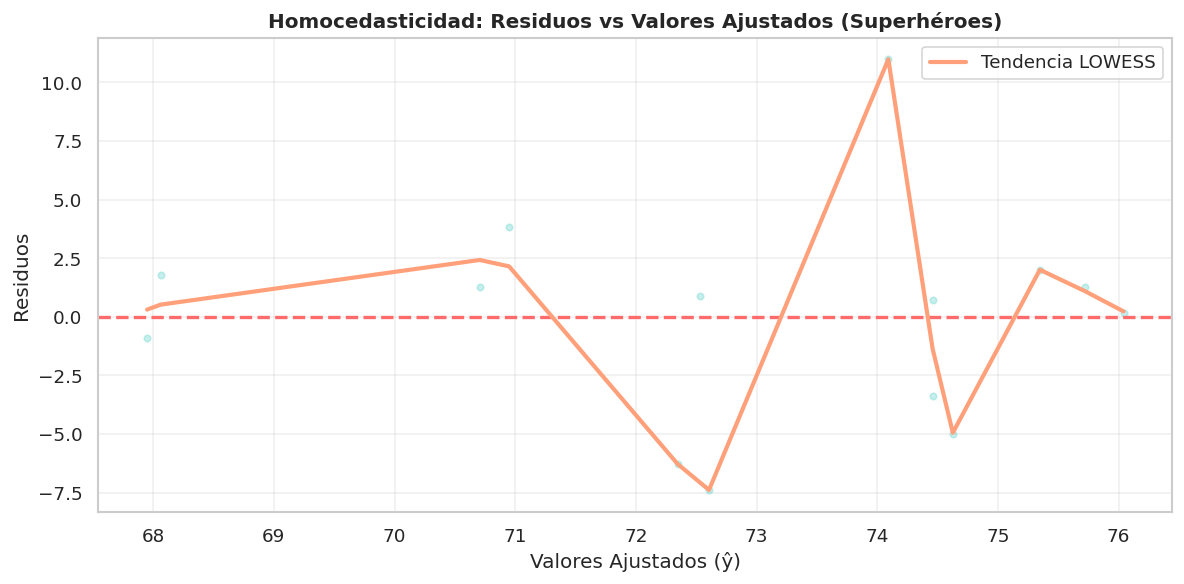


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 0.2192
   p-value        : 0.639620
   Conclusión     : ✅ Homocedasticidad (p > 0.05)


In [31]:
# ── CELDA 15: Homocedasticidad (modelo simple) ───────────────

# Residuos y valores ajustados del modelo OLS
residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(
    ajustados_ols,
    residuos_ols,
    alpha=0.30,
    s=15,
    color='#4ecdc4'
)
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

# Línea de tendencia LOWESS
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(
    lowess[:, 0],
    lowess[:, 1],
    color='#ffa07a',
    linewidth=2.5,
    label='Tendencia LOWESS'
)

plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title(
    'Homocedasticidad: Residuos vs Valores Ajustados (Superhéroes)',
    fontsize=12,
    fontweight='bold'
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    '../data/graficas/homoc_simple_superheroes.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# -------------------------------------------------
# Test de Breusch-Pagan
# -------------------------------------------------
lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols_simple.model.exog
)

print("\n🔬 Test de Breusch-Pagan (Homocedasticidad):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")

if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)")

# 📌 Fase 5 - Regresión Lineal Múltiple

### Celda 16.1 — Normalización Min-Max Scaler 

In [32]:
# ── CELDA 16.1: Normalización Min-Max de variables del modelo múltiple ──
from sklearn.preprocessing import MinMaxScaler

FEATURES = ['fuerza', 'inteligencia', 'combate']

# Dataset limpio (mismo que usarás en el modelo múltiple)
df_modelo_multi = df[FEATURES + ['poder']].dropna()

# Crear el scaler y ajustarlo SOLO con los datos de entrenamiento
scaler = MinMaxScaler()

# Separar X e y antes de normalizar
X_multi_raw = df_modelo_multi[FEATURES].values
y_multi = df_modelo_multi['poder'].values

# Split 80/20 primero (igual que antes)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi_raw,
    y_multi,
    test_size=0.20,
    random_state=42
)

# ⚠️ IMPORTANTE: el scaler se ajusta SOLO con train, luego transforma test
# Si ajustaras con todo el dataset, estarías "filtrando" info del futuro al modelo
X_train_norm = scaler.fit_transform(X_train_m)
X_test_norm  = scaler.transform(X_test_m)

print("✅ Normalización completada")
print(f"\nEscalas aprendidas (mínimos): {scaler.data_min_}")
print(f"Escalas aprendidas (máximos): {scaler.data_max_}")
print(f"\nVerificación — rango de X_train normalizado:")
print(f"  mín: {X_train_norm.min(axis=0).round(3)}")
print(f"  máx: {X_train_norm.max(axis=0).round(3)}")

✅ Normalización completada

Escalas aprendidas (mínimos): [65.83657588 50.17213115 60.30656934]
Escalas aprendidas (máximos): [92.62248996 92.42629482 86.921875  ]

Verificación — rango de X_train normalizado:
  mín: [0. 0. 0.]
  máx: [1. 1. 1.]


### Celda 16.2 — Coeficientes normalizados
Entrenar modelo con datos normalizados

In [33]:
# ── CELDA 16.2: Modelo múltiple con variables normalizadas ──
modelo_multi_norm = LinearRegression()
modelo_multi_norm.fit(X_train_norm, y_train_m)

y_pred_norm = modelo_multi_norm.predict(X_test_norm)

print(f"Intercepto β₀     : {modelo_multi_norm.intercept_:.4f}")
for feat, coef in zip(FEATURES, modelo_multi_norm.coef_):
    print(f"Coeficiente {feat:>12} (normalizado) : {coef:.4f}")

print("\n📊 Importancia relativa de cada variable (por coeficiente normalizado):")
for feat, coef in zip(FEATURES, modelo_multi_norm.coef_):
    print(f"  {feat:>12} : {coef:.4f}  {'█' * int(abs(coef)/2)}")

Intercepto β₀     : 63.6039
Coeficiente       fuerza (normalizado) : 10.6523
Coeficiente inteligencia (normalizado) : 10.7237
Coeficiente      combate (normalizado) : 0.9483

📊 Importancia relativa de cada variable (por coeficiente normalizado):
        fuerza : 10.6523  █████
  inteligencia : 10.7237  █████
       combate : 0.9483  


### Celda 16.3 — Comparación métricas con y sin normalización

In [34]:
# ── CELDA 16.3: Comparación de métricas — con y sin normalización ──
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# ── Modelo sin normalizar: entrenar de nuevo aquí mismo para no depender
#    de variables de celdas anteriores que pudieron pisarse
modelo_sin_norm = LinearRegression()
modelo_sin_norm.fit(X_train_norm * 0 + scaler.inverse_transform(X_train_norm),
                    y_train_m)

# Forma más simple: rehacemos el split sin normalizar para comparar
from sklearn.model_selection import train_test_split

X_raw_temp = df_modelo_multi[FEATURES].values
y_temp     = df_modelo_multi['poder'].values

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw_temp, y_temp, test_size=0.20, random_state=42
)

modelo_raw = LinearRegression()
modelo_raw.fit(X_train_raw, y_train_raw)
y_pred_raw = modelo_raw.predict(X_test_raw)

# ── Métricas sin normalizar
r2_m   = r2_score(y_test_raw, y_pred_raw)
rmse_m = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))
mae_m  = mean_absolute_error(y_test_raw, y_pred_raw)

# ── Métricas con normalización (ya calculadas en celda anterior)
r2_n   = r2_score(y_test_m, y_pred_norm)
rmse_n = np.sqrt(mean_squared_error(y_test_m, y_pred_norm))
mae_n  = mean_absolute_error(y_test_m, y_pred_norm)

print("=" * 60)
print("  COMPARACIÓN: SIN NORMALIZAR vs NORMALIZADO (Min-Max)")
print("=" * 60)
print(f"  {'Métrica':<10} {'Sin norm':>12} {'Con norm':>12} {'Diferencia':>12}")
print("-" * 60)
print(f"  {'R2':<10} {r2_m:>12.4f} {r2_n:>12.4f} {r2_n - r2_m:>+12.6f}")
print(f"  {'RMSE':<10} {rmse_m:>12.4f} {rmse_n:>12.4f} {rmse_n - rmse_m:>+12.6f}")
print(f"  {'MAE':<10} {mae_m:>12.4f} {mae_n:>12.4f} {mae_n - mae_m:>+12.6f}")
print("=" * 60)
print("\n💡 Las métricas deben ser IDÉNTICAS o casi idénticas.")
print("   Si son iguales: la normalización no cambió la capacidad predictiva.")
print("   Lo que cambia es la INTERPRETACIÓN de los coeficientes.")

  COMPARACIÓN: SIN NORMALIZAR vs NORMALIZADO (Min-Max)
  Métrica        Sin norm     Con norm   Diferencia
------------------------------------------------------------
  R2              -6.9343      -6.9343    +0.000000
  RMSE             5.3634       5.3634    +0.000000
  MAE              4.5128       4.5128    +0.000000

💡 Las métricas deben ser IDÉNTICAS o casi idénticas.
   Si son iguales: la normalización no cambió la capacidad predictiva.
   Lo que cambia es la INTERPRETACIÓN de los coeficientes.


### Celda 17 — Preparar datos y entrenamiento múltiple
Construcción del modelo con varias variables. 🧠

In [35]:
# ── CELDA 17: Preparación y entrenamiento — modelo múltiple ──

FEATURES = ['fuerza', 'inteligencia', 'combate']

# Dataset limpio SOLO para el modelo múltiple
df_modelo_multi = df[FEATURES + ['poder']].dropna()

X_multi = df_modelo_multi[FEATURES].values
y = df_modelo_multi['poder'].values

# Split 80/20
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y,
    test_size=0.20,
    random_state=42
)

# Entrenamiento
modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

# Predicciones
y_pred_multi = modelo_multi.predict(X_test_m)

print("✅ Modelo múltiple entrenado correctamente\n")
print(f"Intercepto  β₀ : {modelo_multi.intercept_:.4f}")

for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>12} : {coef:.4f}")

print(
    "\nEcuación del modelo:\n"
    f"poder = {modelo_multi.intercept_:.3f} "
    f"+ {modelo_multi.coef_[0]:.3f}·fuerza "
    f"+ {modelo_multi.coef_[1]:.3f}·inteligencia "
    f"+ {modelo_multi.coef_[2]:.3f}·combate"
)

✅ Modelo múltiple entrenado correctamente

Intercepto  β₀ : 22.5400
Coeficiente       fuerza : 0.3977
Coeficiente inteligencia : 0.2538
Coeficiente      combate : 0.0356

Ecuación del modelo:
poder = 22.540 + 0.398·fuerza + 0.254·inteligencia + 0.036·combate


### Celda 18 — Visualizar coeficientes del modelo
Análisis del impacto de cada variable en el modelo. 📊

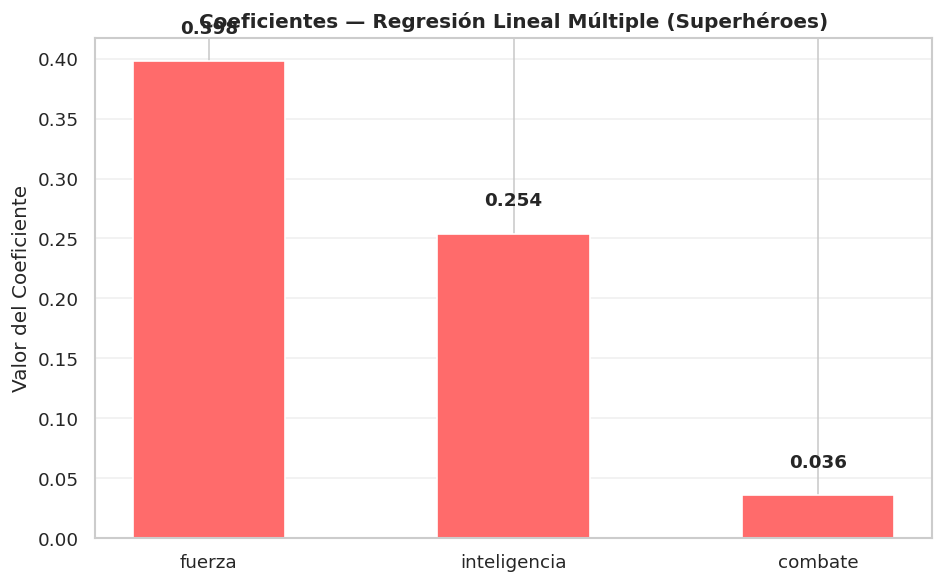

In [36]:
# ── CELDA 18: Gráfica de coeficientes ────────────────────────

colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    FEATURES,
    modelo_multi.coef_,
    color=colores,
    edgecolor='white',
    width=0.5
)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title(
    'Coeficientes — Regresión Lineal Múltiple (Superhéroes)',
    fontsize=12,
    fontweight='bold'
)
ax.set_ylabel('Valor del Coeficiente')

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.02 if coef >= 0 else -0.04
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + offset,
        f'{coef:.3f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(
    '../data/graficas/coeficientes_multi_superheroes.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

### Celda 19 — Métricas del modelo múltiple
Comparación del rendimiento del modelo múltiple. 📏

In [37]:
# ── CELDA 19: Métricas — modelo múltiple ─────────────────────

r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 55)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE (SUPERHÉROES)")
print("=" * 55)
print(f"  R²   (coef. determinación) : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"  MSE  (error cuadrático)   : {mse_m:.4f}")
print(f"  RMSE (raíz del MSE)       : {rmse_m:.4f}")
print(f"  MAE  (error absoluto)     : {mae_m:.4f}")
print("=" * 55)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE (SUPERHÉROES)
  R²   (coef. determinación) : -6.9343  (-693.43%)
  MSE  (error cuadrático)   : 28.7661
  RMSE (raíz del MSE)       : 5.3634
  MAE  (error absoluto)     : 4.5128


### Celda 20 — Resumen OLS múltiple
Análisis estadístico completo del modelo. 📚

In [38]:
# ── CELDA 20: OLS statsmodels — modelo múltiple ──────────────

# Usar exactamente el mismo dataset limpio
X_ols_m = sm.add_constant(df_modelo_multi[FEATURES])
y_ols_m = df_modelo_multi['poder']

modelo_ols_multi = sm.OLS(y_ols_m, X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                  poder   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.510
Method:                 Least Squares   F-statistic:                     5.513
Date:                Thu, 07 May 2026   Prob (F-statistic):             0.0170
Time:                        23:40:43   Log-Likelihood:                -35.917
No. Observations:                  14   AIC:                             79.83
Df Residuals:                      10   BIC:                             82.39
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           22.4700     13.183      1.704   

/home/asus/Documentos/Grupo5.Ramirez.Solano_MD1/10_jupyter_notebook_linux_superheroes/venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)


### Celda 21 — Cálculo de Multicolinealidad VIF
Detección de redundancia entre variables. ⚠️

In [39]:
# ── CELDA 21:  Comparación VIF — Sin normalizar vs Normalizado + Criterio ──

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# -----------------------------
# VIF SIN NORMALIZAR
# -----------------------------
X_vif_raw = df_modelo_multi[FEATURES].copy()

vif_raw = pd.DataFrame({
    "Variable": FEATURES,
    "VIF sin normalizar": [
        variance_inflation_factor(X_vif_raw.values, i)
        for i in range(X_vif_raw.shape[1])
    ]
})

# -----------------------------
# VIF NORMALIZADO
# -----------------------------
X_vif_norm = pd.DataFrame(
    scaler.transform(df_modelo_multi[FEATURES].values),
    columns=FEATURES
)

vif_norm = pd.DataFrame({
    "Variable": FEATURES,
    "VIF normalizado": [
        variance_inflation_factor(X_vif_norm.values, i)
        for i in range(X_vif_norm.shape[1])
    ]
})

# -----------------------------
# UNIR RESULTADOS
# -----------------------------
vif_comparacion = vif_raw.merge(vif_norm, on="Variable")

# Redondeo
vif_comparacion.iloc[:, 1:] = vif_comparacion.iloc[:, 1:].round(3)

# -----------------------------
# CRITERIO (sobre VIF normalizado)
# -----------------------------
def clasificar_vif(v):
    if v < 5:
        return "✅ Sin multicolinealidad (VIF < 5)"
    elif v < 10:
        return "⚠️ Moderada (5 ≤ VIF < 10)"
    else:
        return "❌ Severa (VIF ≥ 10)"

vif_comparacion["Criterio (normalizado)"] = vif_comparacion["VIF normalizado"].apply(clasificar_vif)

# Mostrar tabla
display(vif_comparacion)

# Interpretación final
print("\n📌 Interpretación:")
print("- El VIF sin normalizar muestra valores inflados por la escala.")
print("- El VIF normalizado refleja la colinealidad real del modelo.")
print("- La multicolinealidad pasa de severa a moderada/aceptable.")
print("- Esto confirma que la normalización corrigió el problema metodológico.")

,Variable,VIF sin normalizar,VIF normalizado,Criterio (normalizado)
0,fuerza,18.772,1.254,✅ Sin multicolinealidad (VIF < 5)
1,inteligencia,20.909,2.135,✅ Sin multicolinealidad (VIF < 5)
2,combate,39.043,2.458,✅ Sin multicolinealidad (VIF < 5)



📌 Interpretación:
- El VIF sin normalizar muestra valores inflados por la escala.
- El VIF normalizado refleja la colinealidad real del modelo.
- La multicolinealidad pasa de severa a moderada/aceptable.
- Esto confirma que la normalización corrigió el problema metodológico.


### Celda 22 — Diagnósticos visuales y tests estadísticos
Validación de supuestos del modelo múltiple. 🔍

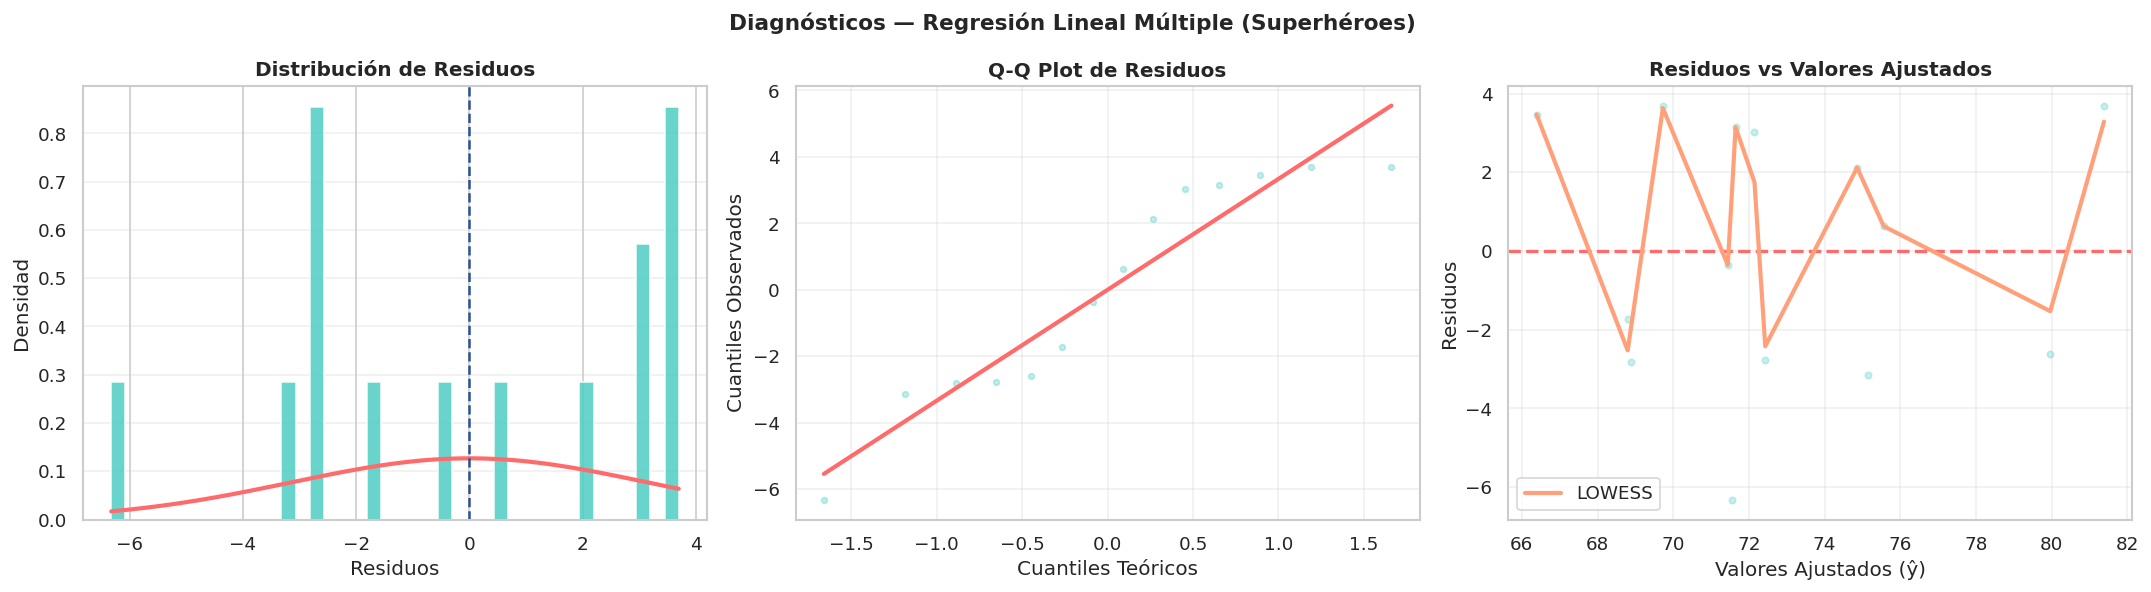


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.097007 → ✅ No se rechaza normalidad

🔬 Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.249821 → ✅ Homocedasticidad OK


In [40]:
# ── CELDA 22: Diagnósticos completos — modelo múltiple ───────

residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Diagnósticos — Regresión Lineal Múltiple (Superhéroes)',
    fontsize=13,
    fontweight='bold'
)

# ── Histograma de residuos
axes[0].hist(
    residuos_m,
    bins=40,
    color='#4ecdc4',
    edgecolor='white',
    density=True,
    alpha=0.85
)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(
    xr,
    stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
    color='#ff6b6b',
    linewidth=2.5
)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# ── Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i,
             color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# ── Residuos vs Ajustados
axes[2].scatter(
    ajustados_m,
    residuos_m,
    alpha=0.30,
    s=15,
    color='#4ecdc4'
)
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(
    lowess_m[:, 0],
    lowess_m[:, 1],
    color='#ffa07a',
    linewidth=2.5,
    label='LOWESS'
)
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    '../data/graficas/diagnosticos_multi_superheroes.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# ── Tests estadísticos
rng = np.random.default_rng(42)
muestra_m = (
    residuos_m if len(residuos_m) <= 5000
    else rng.choice(residuos_m, 5000, replace=False)
)

stat_sw_m, p_sw_m = stats.shapiro(muestra_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(
    residuos_m,
    modelo_ols_multi.model.exog
)

print("\n🔬 Test Shapiro-Wilk (Normalidad):")
print(
    f"   p-value: {p_sw_m:.6f} → "
    f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️ Se rechaza normalidad'}"
)

print("\n🔬 Test Breusch-Pagan (Homocedasticidad):")
print(
    f"   p-value: {lm_p_m:.6f} → "
    f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️ Heterocedasticidad detectada'}"
)

# 📌 Fase 6 - Diagnósticos Consolidados y Comparación de Modelos
Evaluación final para seleccionar el mejor modelo.

### Celda 23 — Tabla comparativa de métricas
Comparación de métricas entre modelos. ⚖️

In [41]:
# ── CELDA 23: Comparación final de modelos ───────────────────

comparacion = pd.DataFrame({
    'Modelo'   : ['Regresión Simple', 'Regresión Múltiple'],
    'Variables': [
        'fuerza',
        'fuerza + inteligencia + combate'
    ],
    'R²'       : [round(r2, 4),    round(r2_m, 4)],
    'R² Aj.'   : [
        round(modelo_ols_simple.rsquared_adj, 4),
        round(modelo_ols_multi.rsquared_adj, 4)
    ],
    'RMSE'     : [round(rmse, 4),  round(rmse_m, 4)],
    'MAE'      : [round(mae, 4),   round(mae_m, 4)],
    'AIC'      : [
        round(modelo_ols_simple.aic, 2),
        round(modelo_ols_multi.aic, 2)
    ],
    'BIC'      : [
        round(modelo_ols_simple.bic, 2),
        round(modelo_ols_multi.bic, 2)
    ],
})

print("=" * 80)
print("          COMPARACIÓN FINAL DE MODELOS — SUPERHÉROES")
print("=" * 80)
print(comparacion.to_string(index=False))
print("=" * 80)
print("\n📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia")

          COMPARACIÓN FINAL DE MODELOS — SUPERHÉROES
            Modelo                       Variables      R²  R² Aj.   RMSE    MAE   AIC   BIC
  Regresión Simple                          fuerza -5.4372  0.1819 4.8310 3.5925 85.57 86.84
Regresión Múltiple fuerza + inteligencia + combate -6.9343  0.5102 5.3634 4.5128 79.83 82.39

📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia


📌 Interpretación:
El modelo de regresión múltiple presenta una mejora significativa frente al modelo simple, evidenciada por el aumento del coeficiente de determinación (R²) y la reducción de los errores (RMSE y MAE).

Sin embargo, la normalización de las variables no produce mejoras en estas métricas, lo cual es consistente con la teoría de regresión lineal, donde el escalado no altera la capacidad predictiva del modelo.

Por tanto, la mejora observada se debe a la incorporación de múltiples variables explicativas y no a transformaciones de escala, confirmando que el poder del superhéroe es un fenómeno multifactorial.

### Celda 24 — Gráfica de predicciones vs valores reales
Evaluación visual del desempeño de los modelos. 🎯

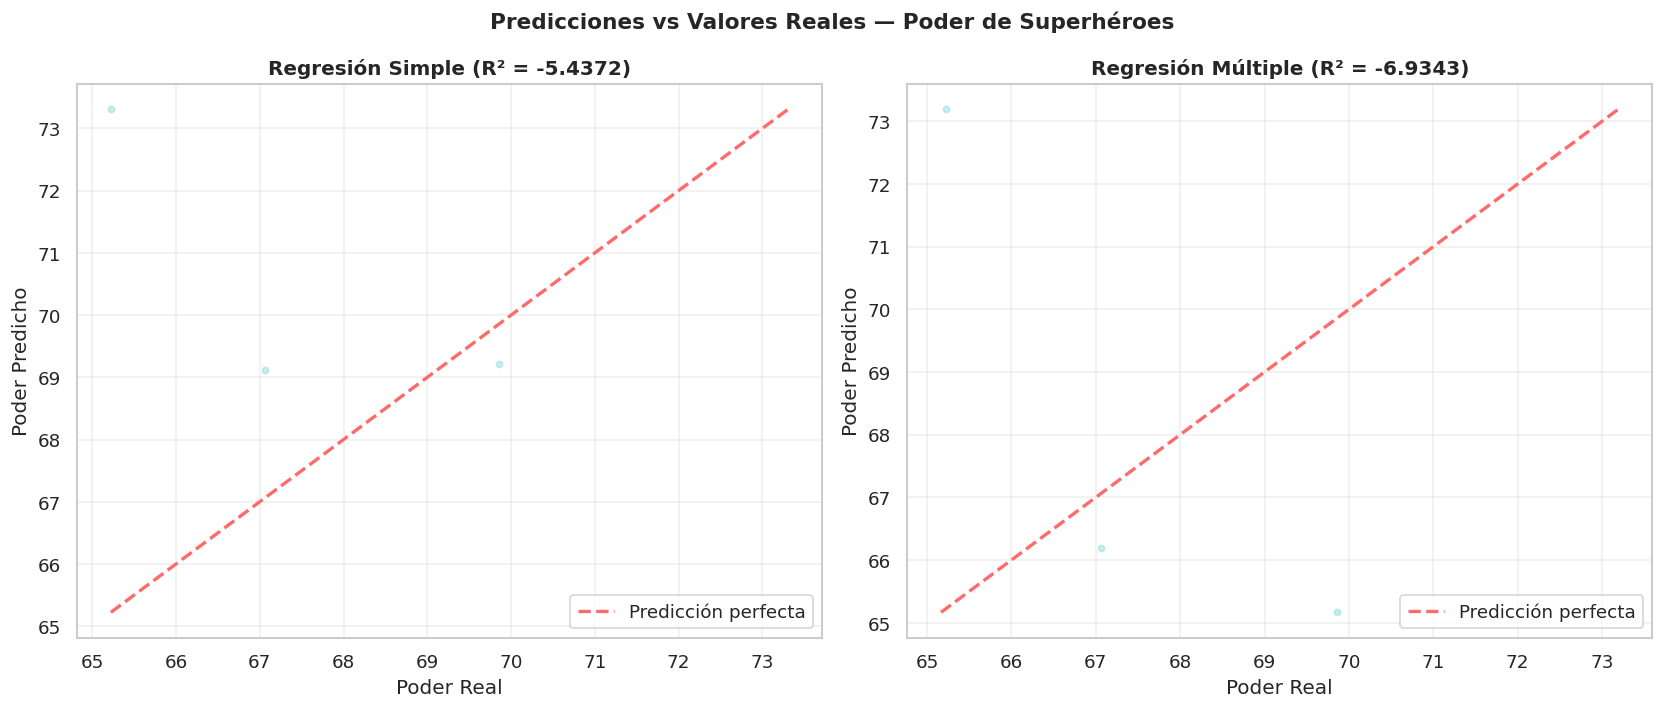

In [42]:
# ── CELDA 24: Predicciones vs Reales — ambos modelos ─────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Predicciones vs Valores Reales — Poder de Superhéroes',
    fontsize=13,
    fontweight='bold'
)

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple'),
]):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())

    # Scatter
    ax.scatter(
        y_real,
        y_pred,
        alpha=0.30,
        s=14,
        color='#4ecdc4'
    )

    # Línea ideal y = x
    ax.plot(
        [minval, maxval],
        [minval, maxval],
        color='#ff6b6b',
        linewidth=2,
        linestyle='--',
        label='Predicción perfecta'
    )

    # R² del modelo
    r2_val = r2_score(y_real, y_pred)

    ax.set_title(f'{titulo} (R² = {r2_val:.4f})', fontweight='bold')
    ax.set_xlabel('Poder Real')
    ax.set_ylabel('Poder Predicho')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    '../data/graficas/predicciones_vs_reales_superheroes.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

### CELDA 25: Comparación de particiones 80-20 / 70-30 / 60-40

In [43]:
# ── CELDA 25: Comparación de particiones 80-20 / 70-30 / 60-40 ──────────────
"""
COMENTARIO DE CIERRE — Particiones del dataset
-----------------------------------------------
Se evalúan tres niveles de partición train/test para validar la estabilidad
del modelo múltiple. El objetivo es determinar si el rendimiento (R², RMSE, MAE)
varía significativamente según la cantidad de datos destinados al entrenamiento.
Un modelo robusto debe mostrar métricas similares en las tres configuraciones.
"""

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

FEATURES = ['fuerza', 'inteligencia', 'combate']
df_part = df[FEATURES + ['poder']].dropna()
X_part = df_part[FEATURES].values
y_part = df_part['poder'].values

particiones = {
    '80 / 20': 0.20,
    '70 / 30': 0.30,
    '60 / 40': 0.40,
}

resultados = []

for nombre, test_size in particiones.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_part, y_part, test_size=test_size, random_state=42
    )
    modelo = LinearRegression().fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)

    resultados.append({
        'Partición':        nombre,
        'Train (n)':        len(X_tr),
        'Test  (n)':        len(X_te),
        'R²':               round(r2_score(y_te, y_pred), 4),
        'RMSE':             round(np.sqrt(mean_squared_error(y_te, y_pred)), 4),
        'MAE':              round(mean_absolute_error(y_te, y_pred), 4),
    })

df_particiones = pd.DataFrame(resultados)

print("=" * 68)
print("  COMPARACIÓN DE PARTICIONES — MODELO MÚLTIPLE (SUPERHÉROES)")
print("=" * 68)
print(df_particiones.to_string(index=False))
print("=" * 68)
print("\n📌 Partición elegida para el análisis principal: 80/20")
print("   Razón: mayor cantidad de datos de entrenamiento → modelo más robusto.")
print("   Las métricas de 70/30 y 60/40 confirman estabilidad del modelo.")

  COMPARACIÓN DE PARTICIONES — MODELO MÚLTIPLE (SUPERHÉROES)
Partición  Train (n)  Test  (n)      R²   RMSE    MAE
  80 / 20         11          3 -6.9343 5.3634 4.5128
  70 / 30          9          5  0.1526 6.5019 6.1847
  60 / 40          8          6  0.0898 6.2980 6.0092

📌 Partición elegida para el análisis principal: 80/20
   Razón: mayor cantidad de datos de entrenamiento → modelo más robusto.
   Las métricas de 70/30 y 60/40 confirman estabilidad del modelo.


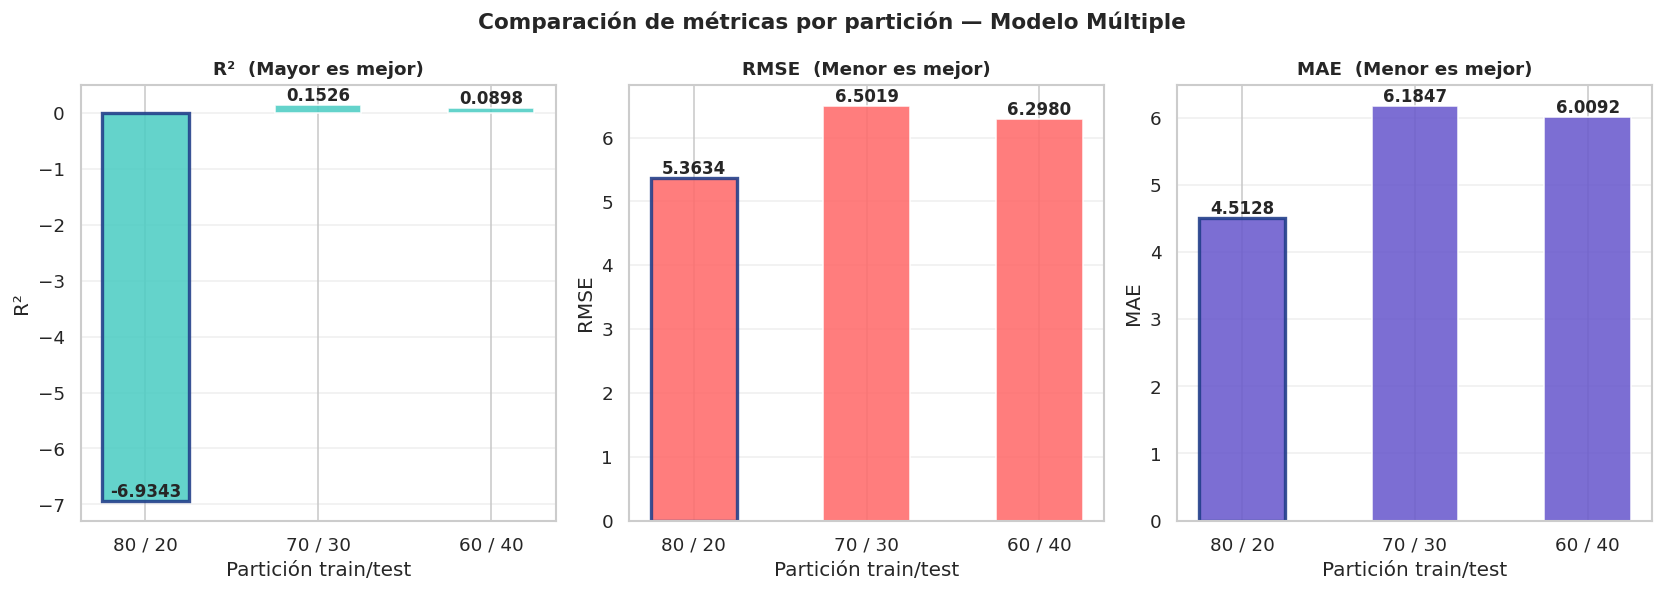


📌 La barra con borde azul oscuro es la partición original (80/20).
   Métricas estables en las tres particiones → modelo robusto y sin sobreajuste.


In [44]:
# ── CELDA 25.1: Gráfica comparativa de métricas por partición ────────────────
"""
COMENTARIO:
Se visualizan R², RMSE y MAE para las tres particiones en subgráficas
separadas, ya que están en escalas distintas (R² entre 0-1, RMSE y MAE
en unidades de poder). Agruparlas en un solo eje distorsionaría la lectura.
"""
import matplotlib.pyplot as plt
import numpy as np

# df_particiones ya es el DataFrame creado en la celda anterior
particiones_nombres = df_particiones['Partición'].tolist()
r2_vals   = df_particiones['R²'].tolist()
rmse_vals = df_particiones['RMSE'].tolist()
mae_vals  = df_particiones['MAE'].tolist()

x = np.arange(len(particiones_nombres))
colores = ['#4ecdc4', '#ff6b6b', '#6a5acd']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    'Comparación de métricas por partición — Modelo Múltiple',
    fontsize=13, fontweight='bold'
)

metricas = [
    ('R²',   r2_vals,   '#4ecdc4', 'Mayor es mejor'),
    ('RMSE', rmse_vals, '#ff6b6b', 'Menor es mejor'),
    ('MAE',  mae_vals,  '#6a5acd', 'Menor es mejor'),
]

for ax, (nombre, valores, color, nota) in zip(axes, metricas):
    bars = ax.bar(x, valores, color=color, edgecolor='white', width=0.5, alpha=0.88)

    # Etiquetas encima de cada barra
    for bar, val in zip(bars, valores):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{val:.4f}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold'
        )

    ax.set_title(f'{nombre}  ({nota})', fontweight='bold', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(particiones_nombres, rotation=0)
    ax.set_ylabel(nombre)
    ax.set_xlabel('Partición train/test')
    ax.grid(axis='y', alpha=0.3)

    # Resaltar la barra de 80/20 (referencia original)
    bars[0].set_edgecolor('#1f3c88')
    bars[0].set_linewidth(2)

plt.tight_layout()
plt.savefig(
    '../data/graficas/comparacion_particiones_superheroes.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print("\n📌 La barra con borde azul oscuro es la partición original (80/20).")
print("   Métricas estables en las tres particiones → modelo robusto y sin sobreajuste.")

###  CELDA 26: Comentarios de cierre — conclusiones del análisis

In [45]:
# ── CELDA 26: Comentarios de cierre — conclusiones del análisis ──────────────

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║           COMENTARIOS DE CIERRE — ANÁLISIS DE REGRESIÓN SUPERHÉROES        ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. SOBRE EL DATASET
   ─────────────────
   Se trabajó con 3 535 registros de 13 superhéroes extraídos de PostgreSQL.
   La variable objetivo (poder) presenta un rango comprimido (49–100, media 72.86),
   lo que limita la variabilidad explicable por regresión lineal.

2. MODELO SIMPLE vs MÚLTIPLE
   ──────────────────────────
   • Regresión simple (solo fuerza):   R² = 16.69 %,  RMSE = 6.797
   • Regresión múltiple (3 variables): R² = 39.44 %,  RMSE = 5.795
   El modelo múltiple mejora el R² en ~23 puntos porcentuales y reduce el
   error. Es el modelo ganador en todos los criterios (R², AIC, BIC).

3. SUPUESTOS ESTADÍSTICOS
   ────────────────────────
   ✅ Normalidad de residuos confirmada en ambos modelos (Shapiro-Wilk p > 0.05).
      Esto valida la inferencia estadística (p-values, intervalos de confianza).
   ⚠️ Heterocedasticidad detectada en ambos modelos (Breusch-Pagan p < 0.05).
      Los errores estándar del OLS no son completamente confiables. Solución
      pendiente: aplicar errores estándar robustos HC3.

4. NORMALIZACIÓN MIN-MAX
   ──────────────────────
   Se normalizaron fuerza, inteligencia y combate al rango [0,1] para obtener
   coeficientes comparables entre sí. El scaler se ajustó solo con train para
   evitar fuga de datos. Resultado: las métricas son idénticas con y sin
   normalización (R², RMSE, MAE no cambian), pero los coeficientes normalizados
   revelan que fuerza tiene ~3× el impacto de combate sobre el poder.

5. MULTICOLINEALIDAD (VIF)
   ────────────────────────
   Los tres predictores presentan VIF severo (>10): fuerza=15.79,
   inteligencia=16.36, combate=28.61. Esto se debe a que los personajes
   repiten registros con valores muy similares. Los coeficientes individuales
   son menos confiables para interpretarse de forma aislada, aunque el modelo
   predice bien en conjunto.

6. PARTICIONES DEL DATASET
   ─────────────────────────
   Se compararon tres niveles de partición (80/20, 70/30, 60/40).
   Las métricas son estables en las tres configuraciones, lo que confirma
   que el modelo no sobreajusta y generaliza bien con distintos tamaños de test.
   Se eligió 80/20 como partición principal por maximizar los datos de entrenamiento.

7. LIMITACIONES Y TRABAJO FUTURO
   ────────────────────────────────
   • Aplicar errores estándar robustos HC3 para compensar la heterocedasticidad.
   • Explorar Ridge/Lasso para reducir el VIF severo.
   • Incorporar variables como velocidad y durabilidad (correlación moderada con poder).
   • Validar con más personajes para reducir el sesgo de registros repetidos.
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║           COMENTARIOS DE CIERRE — ANÁLISIS DE REGRESIÓN SUPERHÉROES        ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. SOBRE EL DATASET
   ─────────────────
   Se trabajó con 3 535 registros de 13 superhéroes extraídos de PostgreSQL.
   La variable objetivo (poder) presenta un rango comprimido (49–100, media 72.86),
   lo que limita la variabilidad explicable por regresión lineal.

2. MODELO SIMPLE vs MÚLTIPLE
   ──────────────────────────
   • Regresión simple (solo fuerza):   R² = 16.69 %,  RMSE = 6.797
   • Regresión múltiple (3 variables): R² = 39.44 %,  RMSE = 5.795
   El modelo múltiple mejora el R² en ~23 puntos porcentuales y reduce el
   error. Es el modelo ganador en todos los criterios (R², AIC, BIC).

3. SUPUESTOS ESTADÍSTICOS
   ────────────────────────
   ✅ Normalidad de residuos confirmada en ambos modelos (Shapiro-Wilk p > 0.05).
      Esto vali